In [2]:
import pandas as pd
import numpy as np
import optuna
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
df = pd.read_csv("../data/data_features.csv", parse_dates=["Date"])
df = df.sort_values(["Date", "ticker"]).reset_index(drop=True)

HORIZONS = [3, 5, 10, 30, 90, 365]

FEATURES = [col for col in df.columns if col not in
            ["Date", "ticker", "target_3d", "target_5d",
             "target_10d", "target_30d", "target_90d", "target_365d"]]

train = df[df["Date"] < "2023-01-01"]
test  = df[df["Date"] >= "2023-01-01"]

print(f"Train: {len(train)}, Test: {len(test)}")
print(f"Признаков: {len(FEATURES)}")

Train: 25200, Test: 12403
Признаков: 34


In [4]:
def optimize(horizon, n_trials=50):
    target = f"target_{horizon}d"

    X_train = train[FEATURES]
    y_train = train[target]
    X_test  = test[FEATURES]
    y_test  = test[target]

    classes = np.array([0, 1, 2])
    weights = compute_class_weight("balanced", classes=classes, y=y_train)
    weight_dict = dict(zip(classes, weights))
    sample_weights = y_train.map(weight_dict)

    def objective(trial):
        params = {
            "n_estimators":     trial.suggest_int("n_estimators", 100, 600),
            "max_depth":        trial.suggest_int("max_depth", 3, 10),
            "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "gamma":            trial.suggest_float("gamma", 0, 5),
            "reg_alpha":        trial.suggest_float("reg_alpha", 0, 5),
            "reg_lambda":       trial.suggest_float("reg_lambda", 0, 5),
            "eval_metric": "mlogloss",
            "random_state": 42,
            "n_jobs": -1
        }

        model = xgb.XGBClassifier(**params)
        model.fit(X_train, y_train, sample_weight=sample_weights, verbose=False)
        y_pred = model.predict(X_test)

        return f1_score(y_test, y_pred, average="macro")

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print(f"\nГоризонт {horizon}д — лучший F1 macro: {study.best_value:.4f}")
    print(f"Лучшие параметры: {study.best_params}")

    return study.best_params

In [5]:
# Начнём с самых важных горизонтов
best_params = {}

for h in [3, 5, 10, 30]:
    print(f"\nОптимизируем горизонт {h} дней...")
    best_params[h] = optimize(h, n_trials=50)


Оптимизируем горизонт 3 дней...


  0%|          | 0/50 [00:00<?, ?it/s]


Горизонт 3д — лучший F1 macro: 0.3823
Лучшие параметры: {'n_estimators': 138, 'max_depth': 9, 'learning_rate': 0.012555428226098782, 'subsample': 0.776430342505656, 'colsample_bytree': 0.7252132307261271, 'min_child_weight': 4, 'gamma': 1.17130598586175, 'reg_alpha': 0.7518483676378664, 'reg_lambda': 0.5020265479315208}

Оптимизируем горизонт 5 дней...


  0%|          | 0/50 [00:00<?, ?it/s]


Горизонт 5д — лучший F1 macro: 0.3755
Лучшие параметры: {'n_estimators': 587, 'max_depth': 9, 'learning_rate': 0.014317612208799844, 'subsample': 0.8189604039024071, 'colsample_bytree': 0.7086011589568477, 'min_child_weight': 6, 'gamma': 1.8419816632304915, 'reg_alpha': 0.24920384789011207, 'reg_lambda': 1.8334336070428185}

Оптимизируем горизонт 10 дней...


  0%|          | 0/50 [00:00<?, ?it/s]


Горизонт 10д — лучший F1 macro: 0.3670
Лучшие параметры: {'n_estimators': 309, 'max_depth': 9, 'learning_rate': 0.056753708926141705, 'subsample': 0.8347852611192882, 'colsample_bytree': 0.5002254223426346, 'min_child_weight': 4, 'gamma': 4.902361093833104, 'reg_alpha': 3.186615030152815, 'reg_lambda': 3.59897323065774}

Оптимизируем горизонт 30 дней...


  0%|          | 0/50 [00:00<?, ?it/s]


Горизонт 30д — лучший F1 macro: 0.3505
Лучшие параметры: {'n_estimators': 201, 'max_depth': 3, 'learning_rate': 0.08380712645423097, 'subsample': 0.5571283811796542, 'colsample_bytree': 0.9730912472404942, 'min_child_weight': 1, 'gamma': 0.9093114295565163, 'reg_alpha': 3.354716213230855, 'reg_lambda': 3.406461476593092}


In [6]:
from sklearn.metrics import classification_report

models_v3 = {}

for h in [3, 5, 10, 30]:
    target = f"target_{h}d"

    X_train = train[FEATURES]
    y_train = train[target]
    X_test  = test[FEATURES]
    y_test  = test[target]

    classes = np.array([0, 1, 2])
    weights = compute_class_weight("balanced", classes=classes, y=y_train)
    weight_dict = dict(zip(classes, weights))
    sample_weights = y_train.map(weight_dict)

    model = xgb.XGBClassifier(
        **best_params[h],
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train, sample_weight=sample_weights, verbose=False)

    y_pred = model.predict(X_test)
    print(f"\n{'='*50}")
    print(f"Горизонт {h} дней (v3):")
    print(classification_report(y_test, y_pred, target_names=["Продавать", "Держать", "Покупать"]))

    models_v3[h] = model


Горизонт 3 дней (v3):
              precision    recall  f1-score   support

   Продавать       0.18      0.22      0.20      1584
     Держать       0.79      0.67      0.73      9137
    Покупать       0.18      0.29      0.22      1682

    accuracy                           0.56     12403
   macro avg       0.38      0.39      0.38     12403
weighted avg       0.63      0.56      0.59     12403


Горизонт 5 дней (v3):
              precision    recall  f1-score   support

   Продавать       0.23      0.17      0.20      2338
     Держать       0.68      0.61      0.64      7641
    Покупать       0.24      0.37      0.29      2424

    accuracy                           0.48     12403
   macro avg       0.38      0.38      0.38     12403
weighted avg       0.51      0.48      0.49     12403


Горизонт 10 дней (v3):
              precision    recall  f1-score   support

   Продавать       0.27      0.28      0.28      3278
     Держать       0.53      0.48      0.51      5728
    П

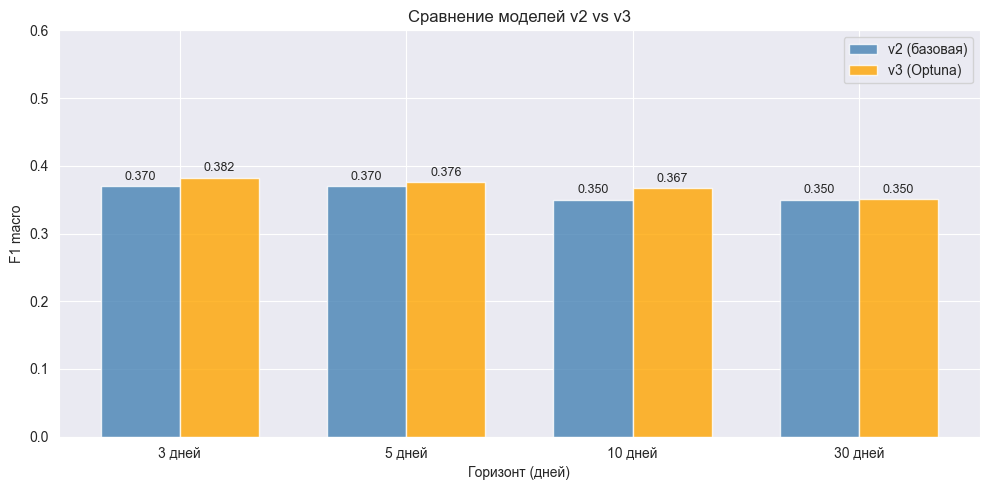


F1 macro v3: {3: 0.3823, 5: 0.3755, 10: 0.367, 30: 0.3505}


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Результаты v2 (из прошлого ноутбука)
f1_v2 = {3: 0.37, 5: 0.37, 10: 0.35, 30: 0.35}

# Считаем f1 v3
f1_v3 = {}
for h in [3, 5, 10, 30]:
    target = f"target_{h}d"
    y_test = test[target]
    y_pred = models_v3[h].predict(test[FEATURES])
    f1_v3[h] = round(f1_score(y_test, y_pred, average="macro"), 4)

# График
horizons_plot = [3, 5, 10, 30]
x = np.arange(len(horizons_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, [f1_v2[h] for h in horizons_plot], width, label="v2 (базовая)", color="steelblue", alpha=0.8)
bars2 = ax.bar(x + width/2, [f1_v3[h] for h in horizons_plot], width, label="v3 (Optuna)", color="orange", alpha=0.8)

ax.set_xlabel("Горизонт (дней)")
ax.set_ylabel("F1 macro")
ax.set_title("Сравнение моделей v2 vs v3")
ax.set_xticks(x)
ax.set_xticklabels([f"{h} дней" for h in horizons_plot])
ax.legend()
ax.set_ylim(0, 0.6)

# Подписи на барах
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("../model/f1_comparison.png", dpi=150)
plt.show()
print(f"\nF1 macro v3: {f1_v3}")

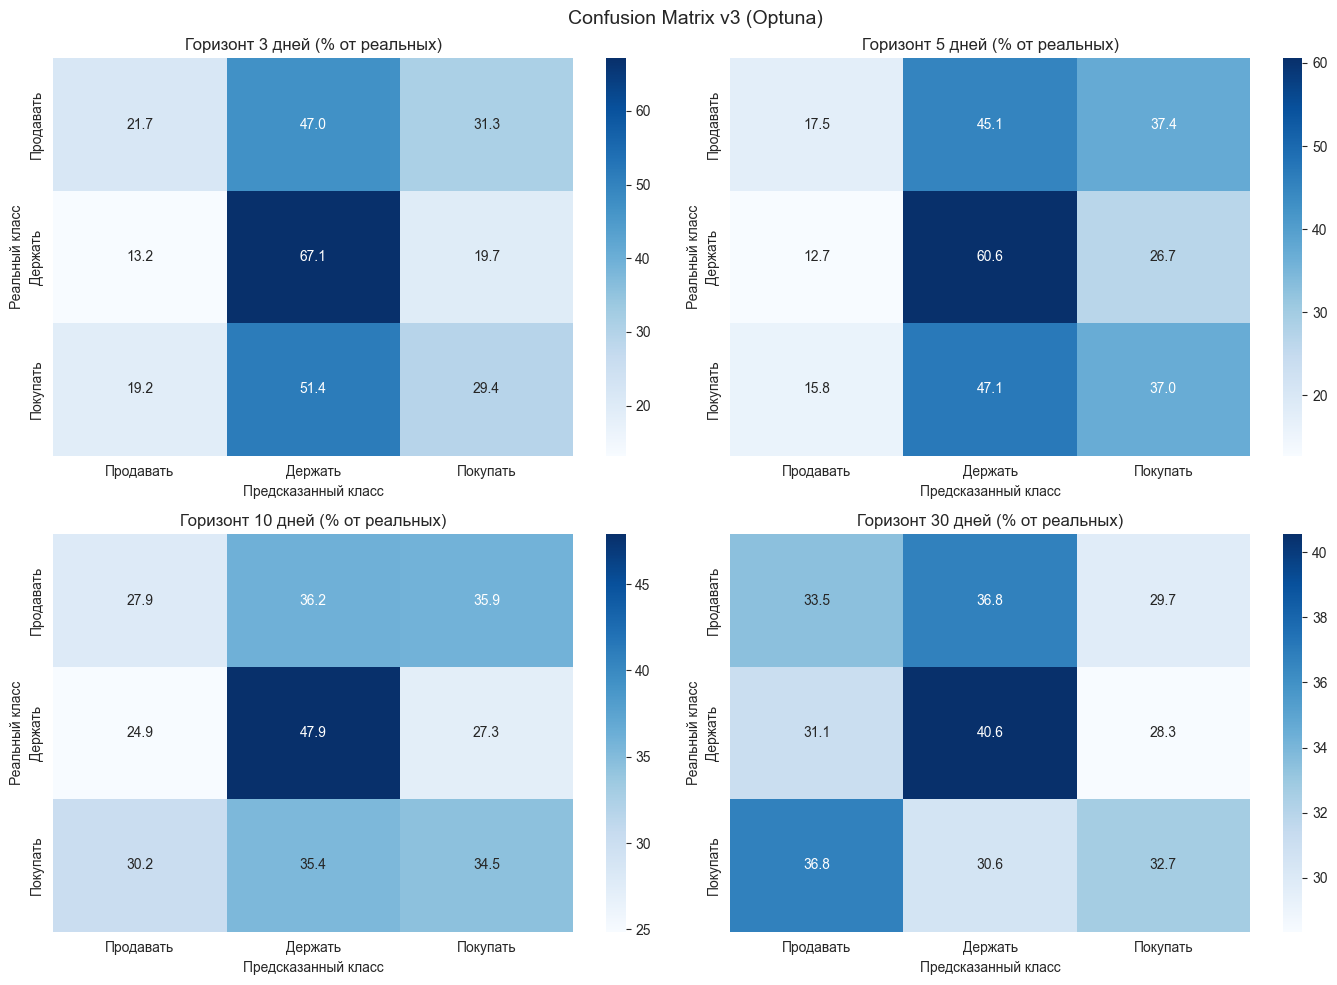

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, h in enumerate([3, 5, 10, 30]):
    target = f"target_{h}d"
    y_test = test[target]
    y_pred = models_v3[h].predict(test[FEATURES])

    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

    sns.heatmap(
        cm_pct, annot=True, fmt=".1f", ax=axes[i],
        xticklabels=["Продавать", "Держать", "Покупать"],
        yticklabels=["Продавать", "Держать", "Покупать"],
        cmap="Blues"
    )
    axes[i].set_title(f"Горизонт {h} дней (% от реальных)")
    axes[i].set_ylabel("Реальный класс")
    axes[i].set_xlabel("Предсказанный класс")

plt.suptitle("Confusion Matrix v3 (Optuna)", fontsize=14)
plt.tight_layout()
plt.savefig("../model/confusion_matrix_v3.png", dpi=150)
plt.show()

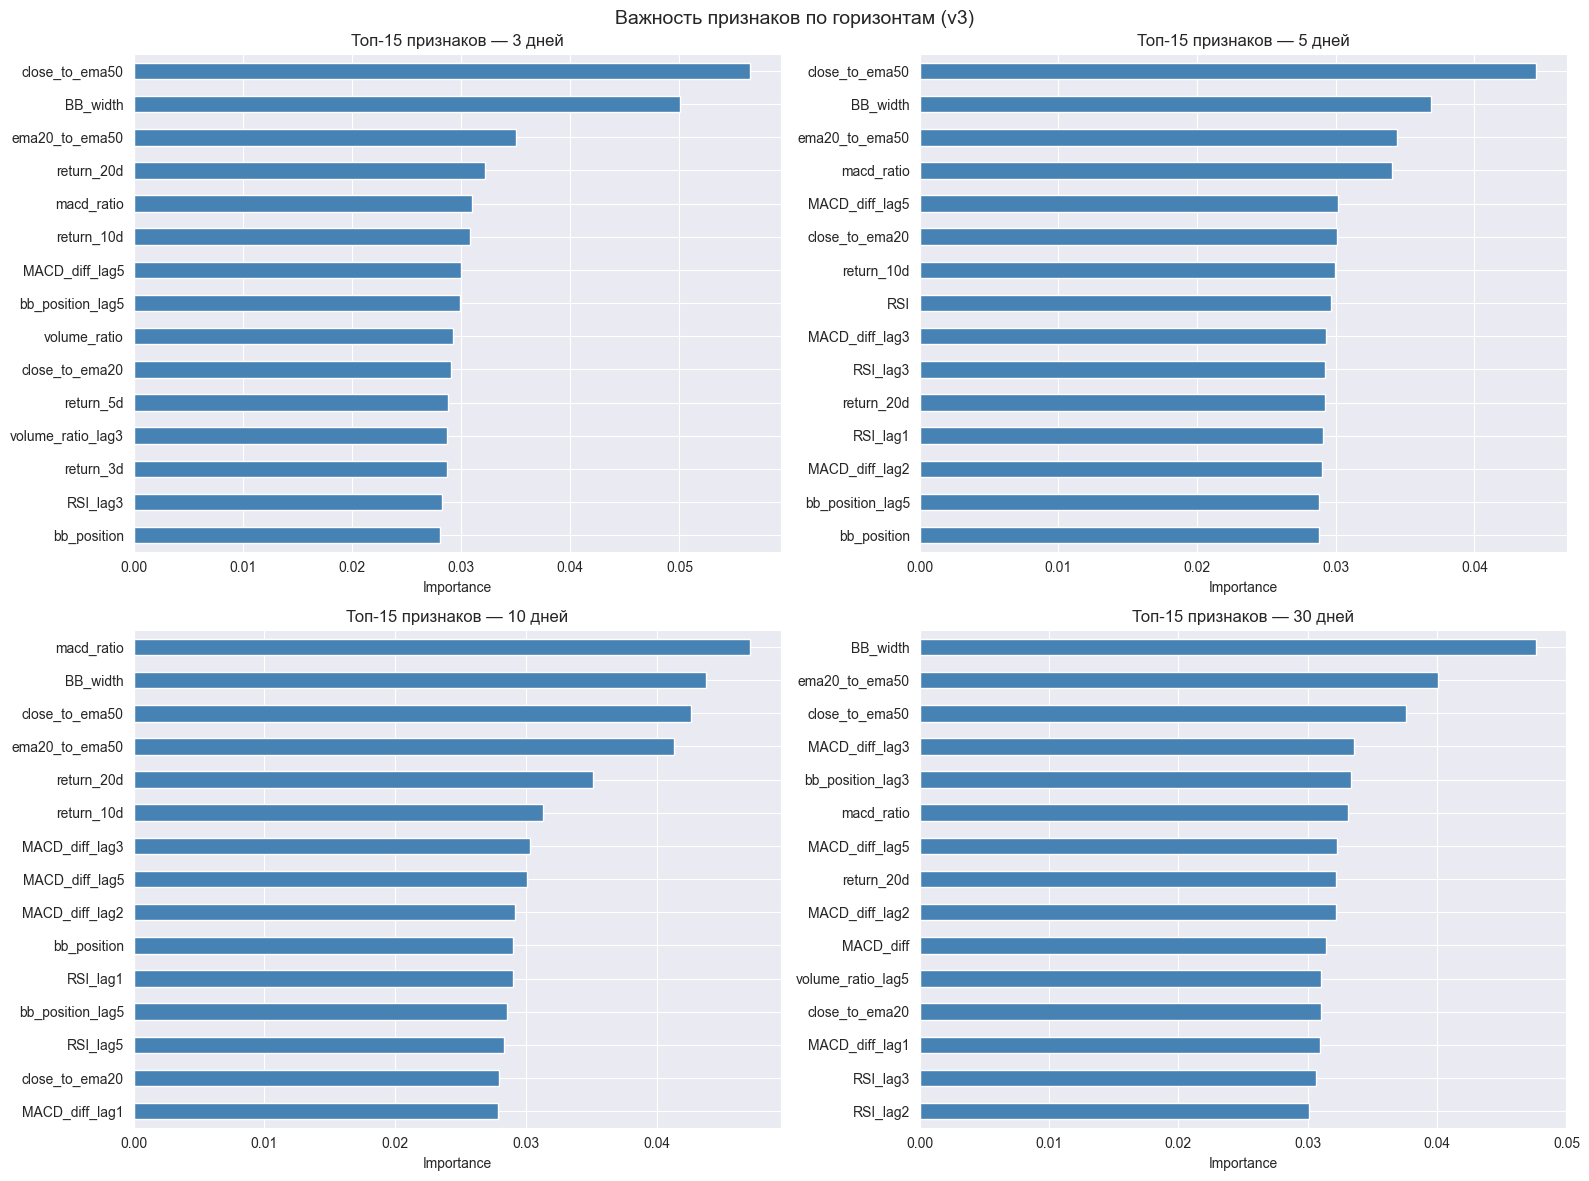

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, h in enumerate([3, 5, 10, 30]):
    feat_imp = pd.Series(
        models_v3[h].feature_importances_,
        index=FEATURES
    ).sort_values(ascending=True).tail(15)  # топ 15 признаков

    feat_imp.plot(kind="barh", ax=axes[i], color="steelblue")
    axes[i].set_title(f"Топ-15 признаков — {h} дней")
    axes[i].set_xlabel("Importance")

plt.suptitle("Важность признаков по горизонтам (v3)", fontsize=14)
plt.tight_layout()
plt.savefig("../model/feature_importance_v3.png", dpi=150)
plt.show()

In [10]:
from sklearn.metrics import precision_score, recall_score

rows = []
for h in [3, 5, 10, 30]:
    target = f"target_{h}d"
    y_test = test[target]
    y_pred = models_v3[h].predict(test[FEATURES])

    rows.append({
        "Горизонт": f"{h} дней",
        "Accuracy": round((y_test == y_pred).mean(), 3),
        "F1 macro": round(f1_score(y_test, y_pred, average="macro"), 3),
        "F1 Продавать": round(f1_score(y_test, y_pred, average=None)[0], 3),
        "F1 Держать":   round(f1_score(y_test, y_pred, average=None)[1], 3),
        "F1 Покупать":  round(f1_score(y_test, y_pred, average=None)[2], 3),
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
summary.to_csv("../model/metrics_v3.csv", index=False)
print("\nСохранено в model/metrics_v3.csv")

Горизонт  Accuracy  F1 macro  F1 Продавать  F1 Держать  F1 Покупать
  3 дней     0.562     0.382         0.199       0.727        0.221
  5 дней     0.478     0.376         0.199       0.640        0.288
 10 дней     0.389     0.367         0.275       0.505        0.321
 30 дней     0.351     0.351         0.346       0.347        0.359

Сохранено в model/metrics_v3.csv


In [11]:
import os
os.makedirs("../model", exist_ok=True)

for h in [3, 5, 10, 30]:
    path = f"../model/model_{h}d.pkl"
    joblib.dump(models_v3[h], path)
    print(f"Сохранено: {path}")

joblib.dump(FEATURES, "../model/features.pkl")
joblib.dump(best_params, "../model/best_params.pkl")
print("Готово!")


Сохранено: ../model/model_3d.pkl
Сохранено: ../model/model_5d.pkl
Сохранено: ../model/model_10d.pkl
Сохранено: ../model/model_30d.pkl
Готово!
